In [1]:
from karabo.imaging.imager import Imager
from karabo.simulation.telescope import Telescope
from karabo.simulation.observation import Observation
from karabo.simulation.interferometer import InterferometerSimulation
from karabo.simulation.sky_model import SkyModel
from karabo.sourcedetection.result import (
    SourceDetectionResult,
    PyBDSFSourceDetectionResult,
)
from karabo.sourcedetection.evaluation import SourceDetectionEvaluation

import matplotlib.pyplot as plt

# Render plots inline
%matplotlib inline

The RASCIL data directory is not available - continuing but any simulations will fail


# Source Detection

## Simulation

GLEAM_ECG.fits is not downloaded yet. Downloading and caching for future uses...


/home/vincenzo/Karabo-Pipeline/karabo/simulation/sky_model.py:452: RuntimeWarning: invalid value encountered in log10
  flux = cfun(flux)


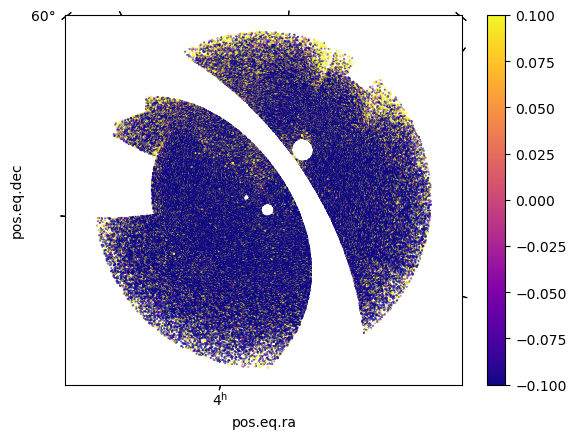

In [2]:
# Get GLEAM Survey Sky
phase_center = [250, -80]
gleam_sky = SkyModel.get_GLEAM_Sky()
gleam_sky.explore_sky(phase_center, s=0.1)

Then we filter the sky model based on radius.

In [3]:
sky = gleam_sky.filter_by_radius(0, 0.5, phase_center[0], phase_center[1])
sky.setup_default_wcs(phase_center=phase_center)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---AIR'  'DEC--AIR'  
CRVAL : 250.0  -80.0  
CRPIX : 0.0  0.0  
PC1_1 PC1_2  : 1.0  0.0  
PC2_1 PC2_2  : 0.0  1.0  
CDELT : -1.0  1.0  
NAXIS : 0  0

Let's have a closer look with the 2d image project explore_sky() provides.

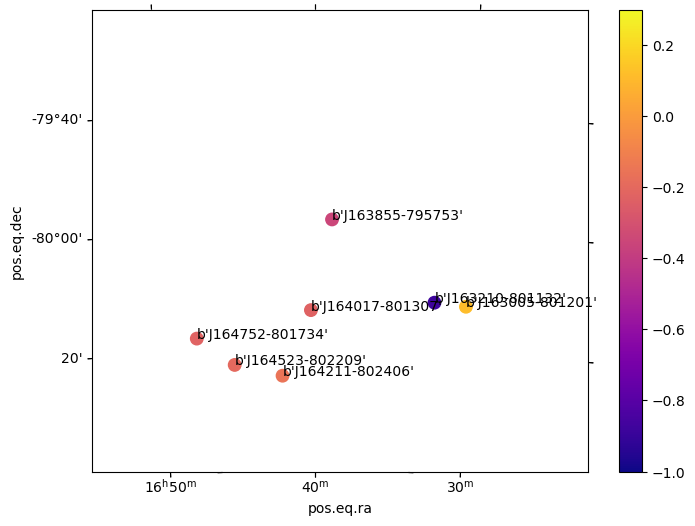

In [4]:
sky.explore_sky(
    phase_center=phase_center,
    figsize=(8, 6),
    xlim=(254, 246),  # RA-lim
    ylim=(-81, -79),  # DEC-lim
    with_labels=True,
    s=80,
    vmin=-1,
    vmax=0.3,
)

### Telescope Module

Various observation parameters and meta information `params` must be passed to the telescope module `oskar.Interferometer` of OSKAR as `oskar.SettingsTree`.

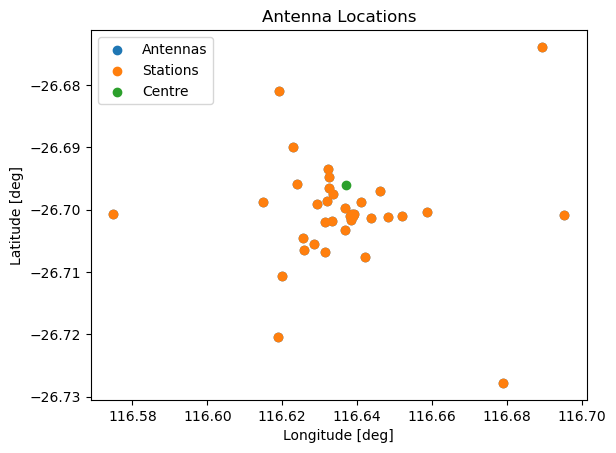

In [43]:
askap_tel = Telescope.get_ASKAP_Telescope()
askap_tel.plot_telescope()

### Observation Simulation

Now the sky module must be passed to the interferometer and the simulation of the observation must be started to generate the measurement set.

In [44]:
observation_settings = Observation(
    start_frequency_hz=100e6,
    phase_centre_ra_deg=phase_center[0],
    phase_centre_dec_deg=phase_center[1],
    number_of_channels=64,
    number_of_time_steps=24,
)

interferometer_sim = InterferometerSimulation(channel_bandwidth_hz=1e6)
visibility_askap = interferometer_sim.run_simulation(
    askap_tel, sky, observation_settings
)

use_gpu is None, using is_cuda_available() to set use_gpu to True


### Dirty Images

We can create dirty images of visibilites and display them as shown below

In [45]:
imaging_npixel = 2048
imaging_cellsize = 3.878509448876288e-05

In [46]:
from __future__ import annotations

import logging
import os
import uuid
from typing import Any, Dict, List, Optional, Tuple, Union

import matplotlib
import matplotlib.pyplot as plt
import numpy
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from numpy.typing import NDArray
from rascil.apps.imaging_qa.imaging_qa_diagnostics import power_spectrum

from karabo.karabo_resource import KaraboResource
from karabo.util.FileHandle import FileHandle, check_ending

# store and restore the previously set matplotlib backend,
# because rascil sets it to Agg (non-GUI)
previous_backend = matplotlib.get_backend()

matplotlib.use(previous_backend)


class Image(KaraboResource):
    def __init__(
        self,
        path: Union[str, FileHandle],
        **kwargs,
    ) -> None:
        """
        Proxy object class for images.
        Dirty, cleaned or any other type of image in a fits format.
        """
        if isinstance(
            path, FileHandle
        ):  # save FileHandle if used to not lose reference and call it's __del__
            self.__file_handle = path
            path_ = path.path
        else:
            path_ = path
        self.path = path_
        self.__name = self.path.split(os.path.sep)[-1]
        self.data, self.header = fits.getdata(self.path, ext=0, header=True, **kwargs)

    @staticmethod
    def read_from_file(path: str) -> Image:
        return Image(path=path)

    def write_to_file(
        self,
        path: str,
        overwrite: bool = False,
    ) -> None:
        """Write an `Image` to `path`  as .fits"""
        check_ending(path=path, ending=".fits")
        fits.writeto(
            filename=path,
            data=self.data,
            header=self.header,
            overwrite=overwrite,
        )

    def header_has_parameters(
        self,
        parameters: List[str],
    ) -> bool:
        for parameter in parameters:
            if parameter not in self.header:
                return False
        return True

    def get_squeezed_data(self) -> NDArray[np.float64]:
        return numpy.squeeze(self.data[:1, :1, :, :])

    def plot(
        self,
        title: Optional[str] = None,
        xlim: Optional[Tuple[float, float]] = None,
        ylim: Optional[Tuple[float, float]] = None,
        figsize: Optional[Tuple[float, float]] = None,
        colobar_label: Optional[str] = None,
        xlabel: Optional[str] = None,
        ylabel: Optional[str] = None,
        cmap: Optional[str] = "jet",
        origin: Optional[str] = "lower",
        wcs_enabled: bool = True,
        invert_xaxis: bool = False,
        filename: Optional[str] = None,
        **kwargs,
    ) -> None:
        """Plots the image

        :param title: the title of the colormap
        :param xlim: RA-limit of plot
        :param ylim: DEC-limit of plot
        :param figsize: figsize as tuple
        :param title: plot title
        :param xlabel: xlabel
        :param ylabel: ylabel
        :param cmap: matplotlib color map
        :param origin: place the [0, 0] index of the array in
        the upper left or lower left corner of the Axes
        :param wcs_enabled: Use wcs transformation?
        :param invert_xaxis: Do you want to invert the xaxis?
        :param filename: Set to path/fname to save figure
        (set extension to fname to overwrite .png default)
        :param kwargs: matplotlib kwargs for scatter & Collections,
        e.g. customize `s`, `vmin` or `vmax`
        """

        if wcs_enabled:
            wcs = WCS(self.header)
            print(wcs)

            slices = []
            for i in range(wcs.pixel_n_dim):
                if i == 0:
                    slices.append("x")
                elif i == 1:
                    slices.append("y")
                else:
                    slices.append(0)

            # create dummy xlim or ylim if only one is set for conversion
            xlim_reset, ylim_reset = False, False
            if xlim is None and ylim is not None:
                xlim = (-1, 1)
                xlim_reset = True
            elif xlim is not None and ylim is None:
                ylim = (-1, 1)
                ylim_reset = True
            if xlim is not None and ylim is not None:
                xlim, ylim = wcs.wcs_world2pix(xlim, ylim, 0)
            if xlim_reset:
                xlim = None
            if ylim_reset:
                ylim = None

        if wcs_enabled:
            fig, ax = plt.subplots(
                figsize=figsize, subplot_kw=dict(projection=wcs, slices=slices)
            )
        else:
            fig, ax = plt.subplots(figsize=figsize)

        im = ax.imshow(self.data[5][0], cmap=cmap, origin=origin, **kwargs)
        ax.grid()
        fig.colorbar(im, label=colobar_label)

        if title is not None:
            ax.set_title(title)
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        if xlabel is not None:
            ax.set_xlabel(xlabel)
        if ylabel is not None:
            ax.set_ylabel(ylabel)
        if invert_xaxis:
            ax.invert_xaxis()
        if filename is not None:
            fig.savefig(filename)
        plt.show(block=False)
        plt.pause(1)

    def get_dimensions_of_image(self) -> List[int]:
        """
        Get the sizes of the dimensions of this Image in an array.
        :return: list with the dimensions.
        """
        result = []
        dimensions = self.header["NAXIS"]
        for dim in np.arange(0, dimensions, 1):
            result.append(self.header[f"NAXIS{dim + 1}"])
        return result

    def get_phase_center(self) -> Tuple[float, float]:
        return float(self.header["CRVAL1"]), float(self.header["CRVAL2"])

    def has_beam_parameters(self) -> bool:
        """
        Check if the image has the beam parameters in the header.
        :param image: Image to check
        :return: True if the image has the beam parameters in the header
        """
        return self.header_has_parameters(
            ["BMAJ", "BMIN", "BPA"],
        )

    def get_quality_metric(self) -> Dict[str, Any]:
        """
        Get image statistics.
        Statistics include :

        - Shape of Image --> 'shape'
        - Max Value --> 'max'
        - Min Value --> 'min'
        - Max Value absolute --> 'max-abs'
        - Root mean square (RMS) --> 'rms'
        - Sum of values --> 'sum'
        - Median absolute --> 'median-abs'
        - Median absolute deviation median --> 'median-abs-dev-median'
        - Median --> 'median'
        - Mean --> 'mean'

        :return: Dictionary holding all image statistics
        """
        # same implementation as RASCIL
        image_stats = {
            "shape": str(self.data.shape),
            "max": np.max(self.data),
            "min": np.min(self.data),
            "max-abs": np.max(np.abs(self.data)),
            "rms": np.std(self.data),
            "sum": np.sum(self.data),
            "median-abs": np.median(np.abs(self.data)),
            "median-abs-dev-median": np.median(
                np.abs(self.data - np.median(self.data))
            ),
            "median": np.median(self.data),
            "mean": np.mean(self.data),
        }

        return image_stats

    def get_power_spectrum(
        self,
        resolution: float = 5.0e-4,
        signal_channel: Optional[int] = None,
    ) -> Tuple[NDArray[np.float64], NDArray[np.floating]]:
        """
        Calculate the power spectrum of this image.

        :param resolution: Resolution in radians needed for conversion from Jy to Kelvin
        :param signal_channel: channel containing both signal and noise
        (arr of same shape as nchan of Image), optional
        :return (profile, theta_axis)
            profile: Brightness temperature for each angular scale in Kelvin
            theta_axis: Angular scale data in degrees
        """
        # use RASCIL for power spectrum
        profile, theta = power_spectrum(self.path, resolution, signal_channel)
        return profile, theta

    def plot_power_spectrum(
        self,
        resolution: float = 5.0e-4,
        signal_channel: Optional[int] = None,
        save_png: bool = False,
    ) -> None:
        """
        Plot the power spectrum of this image.

        :param resolution: Resolution in radians needed for conversion from Jy to Kelvin
        :param signal_channel: channel containing both signal and noise
        (arr of same shape as nchan of Image), optional
        :param save_png: True if result should be saved, default = False
        """
        profile, theta = self.get_power_spectrum(resolution, signal_channel)
        plt.clf()

        plt.plot(theta, profile)
        plt.gca().set_title(
            f"Power spectrum of {self.__name if self.__name is not None else ''} image"
        )
        plt.gca().set_xlabel("Angular scale [degrees]")
        plt.gca().set_ylabel("Brightness temperature [K]")
        plt.gca().set_xscale("log")
        plt.gca().set_yscale("log")
        plt.gca().set_ylim(1e-6 * numpy.max(profile), 2.0 * numpy.max(profile))
        plt.tight_layout()

        if save_png:
            power_spectrum_name = (
                self.__name if self.__name is not None else uuid.uuid4()
            )
            plt.savefig(f"./power_spectrum_{power_spectrum_name}")
        plt.show(block=False)
        plt.pause(1)

    def get_cellsize(self) -> float:
        cdelt1 = self.header["CDELT1"]
        cdelt2 = self.header["CDELT2"]
        if abs(cdelt1) != abs(cdelt2):
            logging.warning(
                "The Images's cdelt1 and cdelt2 are not the same in absolute value."
                + "Continuing with cdelt1"
            )
        return np.deg2rad(np.abs(cdelt1))

    def get_wcs(self) -> WCS:
        return WCS(self.header)

    def get_2d_wcs(
        self,
        invert_ra: bool = True,
    ) -> WCS:
        wcs = WCS(naxis=2)

        def radian_degree(rad: float) -> float:
            return rad * (180 / np.pi)

        cdelt = radian_degree(self.get_cellsize())
        crpix = np.floor((self.get_dimensions_of_image()[0] / 2)) + 1
        wcs.wcs.crpix = np.array([crpix, crpix])
        ra_sign = -1 if invert_ra else 1
        wcs.wcs.cdelt = np.array([ra_sign * cdelt, cdelt])
        wcs.wcs.crval = [self.header["CRVAL1"], self.header["CRVAL2"]]
        wcs.wcs.ctype = ["RA---AIR", "DEC--AIR"]  # coordinate axis type
        return wcs

from typing import Dict, List, Optional, Tuple, Union

import numpy as np
from astropy.wcs import WCS
from distributed import Client
from numpy.typing import NDArray
from rascil.data_models import PolarisationFrame
from rascil.processing_components import (
    convert_blockvisibility_to_stokesI,
    create_blockvisibility_from_ms,
    create_image_from_visibility,
    export_image_to_fits,
    image_gather_channels,
    invert_blockvisibility,
    remove_sumwt,
)
from rascil.workflows import (
    continuum_imaging_skymodel_list_rsexecute_workflow,
    create_blockvisibility_from_ms_rsexecute,
)
from rascil.workflows.rsexecute.execution_support import rsexecute

from karabo.imaging.image import Image
from karabo.simulation.sky_model import SkyModel
from karabo.simulation.visibility import Visibility
from karabo.util.dask import get_global_client
from karabo.util.FileHandle import FileHandle


class Imager:
    """Imager class provides imaging functionality using the visibilities
    of an observation with the help of RASCIL.

    In addition, it provides the calculation of the pixel coordinates of point sources.

    Parameters
    ---------------------------------------------
    visibility : Visibility, required
        Visibility object containing the visibilities of an observation.
    logfile : str, default=None,
        Name of logfile (default is to construct one from msname)
    performance_file : str, default=None
        Name of json file to contain performance information
    ingest_dd : List[int], default=[0],
        Data descriptors in MS to read (all must have the same number of channels)
    ingest_vis_nchan : int, default=None,
        Number of channels in a single data descriptor in the MS
    ingest_chan_per_blockvis : int, defualt=1,
        Number of channels per blockvis (before any average)
    ingest_average_blockvis : Union[bool, str], default=False,
        Average all channels in blockvis.
    imaging_phasecentre : str, default=None
        Phase centre (in SkyCoord string format)
    imaging_pol : str, default="stokesI"
        RASCIL polarisation frame for image
    imaging_nchan : int, default=1,
        Number of channels per image
    imaging_ng_threads : int, default=4,
        Number of Nifty Gridder threads to use (4 is a good choice)
    imaging_w_stacking : Union[bool, str], default=True
        Use the improved w stacking method in Nifty Gridder?
    imaging_flat_sky : Union[bool, str], default=False
        If using a primary beam, normalise to flat sky?
    imaging_npixel : int, default=None
        Number of pixels in ra, dec: Should be a composite of 2, 3, 5
    imaging_cellsize : float, default=None
        Cellsize (radians). Default is to calculate
    override_cellsize : bool, default=False
        Override the cellsize if it is above the critical cellsize
    imaging_weighting : str, default="uniform"
        Type of weighting uniform or robust or natural
    imaging_robustness : float, default=0.0
        Robustness for robust weighting
    imaging_gaussian_taper : float, default=None
        Size of Gaussian smoothing, implemented as taper in weights (rad)
    imaging_dopsf : Union[bool, str], default=False
        Make the PSF instead of the dirty image?
    imaging_dft_kernel : str, default=None
        DFT kernel: cpu_looped | cpu_numba | gpu_raw
    """

    def __init__(
        self,
        visibility: Visibility,
        logfile: Optional[str] = None,
        performance_file: Optional[str] = None,
        ingest_dd: List[int] = [0],
        ingest_vis_nchan: Optional[int] = None,
        ingest_chan_per_blockvis: int = 1,
        ingest_average_blockvis: Union[bool, str] = False,
        imaging_phasecentre: Optional[str] = None,
        imaging_pol: str = "stokesI",
        imaging_nchan: int = 1,
        imaging_context: str = "ng",
        imaging_ng_threads: int = 4,
        imaging_w_stacking: Union[bool, str] = True,
        imaging_flat_sky: Union[bool, str] = False,
        imaging_npixel: Optional[int] = None,
        imaging_cellsize: Optional[float] = None,
        override_cellsize: bool = False,
        imaging_weighting: str = "uniform",
        imaging_robustness: float = 0.0,
        imaging_gaussian_taper: Optional[float] = None,
        imaging_dopsf: Union[bool, str] = False,
        imaging_dft_kernel: Optional[
            str
        ] = None,  # DFT kernel: cpu_looped | cpu_numba | gpu_raw
    ) -> None:
        self.visibility = visibility
        self.logfile = logfile
        self.performance_file = performance_file
        self.ingest_dd = ingest_dd
        self.ingest_vis_nchan = ingest_vis_nchan
        self.ingest_chan_per_blockvis = ingest_chan_per_blockvis
        self.ingest_average_blockvis = ingest_average_blockvis
        self.imaging_phasecentre = imaging_phasecentre
        self.imaging_pol = imaging_pol
        self.imaging_nchan = imaging_nchan
        self.imaging_context = imaging_context
        self.imaging_ng_threads = imaging_ng_threads
        self.imaging_w_stacking = imaging_w_stacking
        self.imaging_flat_sky = imaging_flat_sky
        self.imaging_npixel = imaging_npixel
        self.imaging_cellsize = imaging_cellsize
        self.override_cellsize = override_cellsize
        self.imaging_weighting = imaging_weighting
        self.imaging_robustness = imaging_robustness
        self.imaging_gaussian_taper = imaging_gaussian_taper
        self.imaging_dopsf = imaging_dopsf
        self.imaging_dft_kernel = imaging_dft_kernel

    def get_dirty_image(self) -> Image:
        """Get Dirty Image of visibilities passed to the Imager.
        :return: dirty image of visibilities.
        """

        block_visibilities = create_blockvisibility_from_ms(self.visibility.file.path)
        if len(block_visibilities) != 1:
            raise EnvironmentError("Visibilities are too large")
        visibility = block_visibilities[0]
        file_handle = FileHandle()
        model = create_image_from_visibility(
            visibility,
            npixel=self.imaging_npixel,
            cellsize=self.imaging_cellsize,
            override_cellsize=self.override_cellsize,
        )
        dirty, sumwt = invert_blockvisibility(visibility, model, context="2d")
        export_image_to_fits(dirty, f"{file_handle.path}")
        image = Image(path=file_handle)
        return image

    def imaging_rascil(
        self,
        client: Optional[Client] = None,
        use_dask: bool = False,
        n_threads: int = 1,
        use_cuda: bool = False,  # If True, use CUDA for Nifty Gridder
        # Imaging context: Which nifty gridder to use.
        # See: https://ska-telescope.gitlab.io/external/rascil/RASCIL_wagg.html
        img_context: str = "ng",
        # Number of brightest sources to select for initial SkyModel
        # (if None, use all sources from input file)
        num_bright_sources: Optional[int] = None,
        # Type of deconvolution algorithm (hogbom or msclean or mmclean)
        clean_algorithm: str = "hogbom",
        # Clean beam: major axis, minor axis, position angle (deg) DataFormat. 3 args.
        clean_beam: Optional[Dict[str, float]] = None,
        # Scales for multiscale clean (pixels) e.g. [0, 6, 10]
        clean_scales: List[int] = [0],
        # Number of frequency moments in mmclean (1 is a constant, 2 is linear, etc.)
        clean_nmoment: int = 4,
        clean_nmajor: int = 5,  # Number of major cycles in cip or ical
        # Number of minor cycles in CLEAN (i.e. clean iterations)
        clean_niter: int = 1000,
        clean_psf_support: int = 256,  # Half-width of psf used in cleaning (pixels)
        clean_gain: float = 0.1,  # Clean loop gain
        clean_threshold: float = 1e-4,  # Clean stopping threshold (Jy/beam)
        # Sources with absolute flux > this level (Jy)
        # are fit or extracted using skycomponents
        clean_component_threshold: Optional[float] = None,
        # Method to convert sources in image to skycomponents:
        # 'fit' in frequency or 'extract' actual values
        clean_component_method: str = "fit",
        # Fractional stopping threshold for major cycle
        clean_fractional_threshold: float = 0.3,
        # Number of overlapping facets in faceted clean (along each axis)
        clean_facets: int = 1,
        clean_overlap: int = 32,  # Overlap of facets in clean (pixels)
        # Type of interpolation between facets in deconvolution:
        # (none or linear or tukey)
        clean_taper: str = "tukey",
        # Number of overlapping facets in restore step (along each axis)
        clean_restore_facets: int = 1,
        clean_restore_overlap: int = 32,  # Overlap of facets in restore step (pixels)
        # Type of interpolation between facets in restore step (none, linear or tukey)
        clean_restore_taper: str = "tukey",
        # Type of restored image output: taylor, list, or integrated
        clean_restored_output: str = "list",
    ) -> Tuple[Image, Image, Image]:
        """
        Starts imaging process using RASCIL, will run a CLEAN algorithm
        on the passed visibilities to the Imager.

        :returns (Deconvolved Image, Restored Image, Residual Image)
        """
        if (use_cuda and use_dask) or (use_cuda and client is not None):
            raise EnvironmentError("Cannot use CUDA and Dask at the same time")
        if client and not use_dask:
            raise EnvironmentError("Client passed but use_dask is False")
        if use_dask and not client:
            client = get_global_client()
        if client:
            print(client.cluster)
        # Set CUDA parameters
        if use_cuda:
            img_context = "wg"
        rsexecute.set_client(use_dask=use_dask, client=client, use_dlg=False)

        blockviss = create_blockvisibility_from_ms_rsexecute(
            msname=self.visibility.file.path,
            nchan_per_blockvis=self.ingest_chan_per_blockvis,
            nout=self.ingest_vis_nchan
            // self.ingest_chan_per_blockvis,  # pyright: ignore
            dds=self.ingest_dd,
            average_channels=True,
        )

        blockviss = [
            rsexecute.execute(convert_blockvisibility_to_stokesI)(bv)
            for bv in blockviss
        ]

        models = [
            rsexecute.execute(create_image_from_visibility)(
                bvis,
                npixel=self.imaging_npixel,
                nchan=self.imaging_nchan,
                cellsize=self.imaging_cellsize,
                override_cellsize=self.override_cellsize,
                polarisation_frame=PolarisationFrame("stokesI"),
            )
            for bvis in blockviss
        ]
        result = continuum_imaging_skymodel_list_rsexecute_workflow(
            vis_list=blockviss,  # List of BlockVisibilitys
            model_imagelist=models,  # List of model images
            context=img_context,
            threads=n_threads,
            wstacking=self.imaging_w_stacking
            == "True",  # Correct for w term in gridding
            niter=clean_niter,  # iterations in minor cycle
            nmajor=clean_nmajor,  # Number of major cycles
            algorithm=clean_algorithm,
            gain=clean_gain,  # CLEAN loop gain
            scales=clean_scales,  # Scales for multi-scale cleaning
            fractional_threshold=clean_fractional_threshold,
            # Threshold per major cycle
            threshold=clean_threshold,  # Final stopping threshold
            nmoment=clean_nmoment,
            # Number of frequency moments (1 = no dependence)
            psf_support=clean_psf_support,
            # Support of PSF used in minor cycles (halfwidth in pixels)
            restored_output=clean_restored_output,  # Type of restored image
            deconvolve_facets=clean_facets,
            deconvolve_overlap=clean_overlap,
            deconvolve_taper=clean_taper,
            restore_facets=clean_restore_facets,
            restore_overlap=clean_restore_overlap,
            restore_taper=clean_restore_taper,
            dft_compute_kernel=self.imaging_dft_kernel,
            component_threshold=clean_component_threshold,
            component_method=clean_component_method,
            flat_sky=self.imaging_flat_sky,
            clean_beam=clean_beam,
            clean_algorithm=clean_algorithm,
        )

        result = rsexecute.compute(result, sync=True)

        residual, restored, skymodel = result

        deconvolved = [sm.image for sm in skymodel]
        deconvolved_image_rascil = image_gather_channels(deconvolved)
        file_handle_deconvolved = FileHandle()
        export_image_to_fits(deconvolved_image_rascil, file_handle_deconvolved.path)
        deconvolved_image = Image(path=file_handle_deconvolved.path)

        if isinstance(restored, list):
            restored = image_gather_channels(restored)
        file_handle_restored = FileHandle()
        export_image_to_fits(restored, file_handle_restored.path)
        restored_image = Image(path=file_handle_restored.path)

        residual = remove_sumwt(residual)
        if isinstance(residual, list):
            residual = image_gather_channels(residual)
        file_handle_residual = FileHandle()
        export_image_to_fits(residual, file_handle_residual.path)
        residual_image = Image(path=file_handle_residual.path)

        return deconvolved_image, restored_image, residual_image

    @staticmethod
    def project_sky_to_image(
        sky: SkyModel,
        phase_center: Union[List[int], List[float]],
        imaging_cellsize: float,
        imaging_npixel: int,
        filter_outlier: bool = True,
        invert_ra: bool = True,
    ) -> Tuple[NDArray[np.float64], NDArray[np.int64]]:
        """
        Calculates the pixel coordinates `sky` sources as floats.
        If you want to have integer indices, just round them.

        :param sky: `SkyModel` with the sources
        :param phase_center: [RA,DEC]
        :param imaging_cellsize: Image cellsize in radian (pixel coverage)
        :param imaging_npixel: Number of pixels of the image
        :param filter_outlier: Exclude source outside of image?
        :param invert_ra: Invert RA axis?

        :return: image-coordinates as np.ndarray[px,py] and
        `SkyModel` sources indices as np.ndarray[idxs]
        """
        # calc WCS args
        def radian_degree(rad: float) -> float:
            return rad * (180 / np.pi)

        cdelt = radian_degree(imaging_cellsize)
        crpix = np.floor((imaging_npixel / 2)) + 1

        # setup WCS
        w = WCS(naxis=2)
        w.wcs.crpix = np.array([crpix, crpix])  # coordinate reference pixel per axis
        ra_sign = -1 if invert_ra else 1
        w.wcs.cdelt = np.array(
            [ra_sign * cdelt, cdelt]
        )  # coordinate increments on sphere per axis
        w.wcs.crval = phase_center
        w.wcs.ctype = ["RA---AIR", "DEC--AIR"]  # coordinate axis type

        # convert coordinates
        px, py = w.wcs_world2pix(sky[:, 0], sky[:, 1], 1)

        # check length to cover single source pre-filtering
        if len(px.shape) == 0 and len(py.shape) == 0:
            px, py = [px], [py]
            idxs = np.arange(sky.num_sources)
        # post processing, pre filtering before calling wcs.wcs_world2pix would be
        # more efficient, however this has to be done in the ra-dec space.
        # Maybe for future work!?
        elif filter_outlier:
            px_idxs = np.where(np.logical_and(px <= imaging_npixel, px >= 0))[0]
            py_idxs = np.where(np.logical_and(py <= imaging_npixel, py >= 0))[0]
            idxs = np.intersect1d(px_idxs, py_idxs)
            px, py = px[idxs], py[idxs]
        else:
            idxs = np.arange(sky.num_sources)
        img_coords = np.array([px, py])

        return img_coords, idxs


{'npixel': 2048, 'cellsize': 3.878509448876288e-05, 'override_cellsize': False}
override_cellsize = False
type override_cellsize = <class 'bool'>
cellsize = 3.878509448876288e-05
cellsize = 3.878509448876288e-05
WCS Keywords

Number of WCS axes: 4
CTYPE : 'RA---SIN'  'DEC--SIN'  'STOKES'  'FREQ'  
CRVAL : 250.0  -80.0  1.0  100000000.0  
CRPIX : 1025.0  1025.0  1.0  1.0  
PC1_1 PC1_2 PC1_3 PC1_4  : 1.0  0.0  0.0  0.0  
PC2_1 PC2_2 PC2_3 PC2_4  : 0.0  1.0  0.0  0.0  
PC3_1 PC3_2 PC3_3 PC3_4  : 0.0  0.0  1.0  0.0  
PC4_1 PC4_2 PC4_3 PC4_4  : 0.0  0.0  0.0  1.0  
CDELT : -0.0022222222222222  0.0022222222222222  1.0  1.0  
NAXIS : 2048  2048  1  64


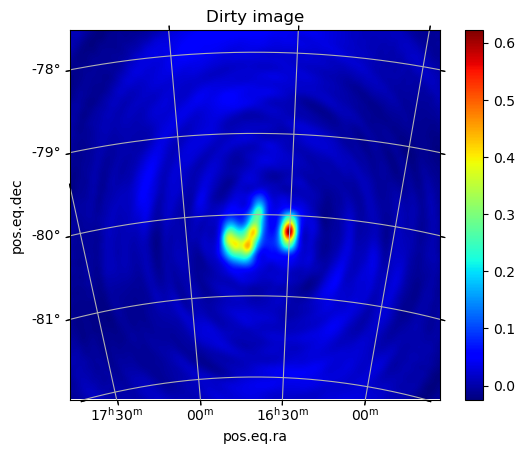

In [47]:
imager_askap = Imager(
    visibility_askap,
    imaging_npixel=imaging_npixel,
    imaging_cellsize=imaging_cellsize,
)
dirty = imager_askap.get_dirty_image()
dirty.plot(title="Dirty image")

In [51]:
dirty.data.shape

(64, 1, 2048, 2048)

In [49]:
dirty.data[5][0].shape

(2048, 2048)

### Source Detection

In [9]:
beam_guess = PyBDSFSourceDetectionResult.guess_beam_parameters(
    imager=imager_askap, method="rascil_1_iter"
)
detection_result_dirty = PyBDSFSourceDetectionResult.detect_sources_in_image(
    image=dirty, beam=beam_guess
)

{'npixel': 2048, 'nchan': 1, 'cellsize': 3.878509448876288e-05, 'override_cellsize': False, 'polarisation_frame': <rascil.data_models.polarisation.PolarisationFrame object at 0x7f573203a9a0>}
override_cellsize = False
type override_cellsize = <class 'bool'>
cellsize = 3.878509448876288e-05
cellsize = 3.878509448876288e-05
{'npixel': 2048, 'nchan': 1, 'cellsize': 3.878509448876288e-05, 'override_cellsize': False, 'polarisation_frame': <rascil.data_models.polarisation.PolarisationFrame object at 0x7f5710191c40>}
override_cellsize = False
type override_cellsize = <class 'bool'>
cellsize = 3.878509448876288e-05
cellsize = 3.878509448876288e-05
{'npixel': 2048, 'nchan': 1, 'cellsize': 3.878509448876288e-05, 'override_cellsize': False, 'polarisation_frame': <rascil.data_models.polarisation.PolarisationFrame object at 0x7f5710191c40>}
override_cellsize = False
type override_cellsize = <class 'bool'>
cellsize = 3.878509448876288e-05
cellsize = 3.878509448876288e-05
{'npixel': 2048, 'nchan': 1,

--> Opened '/home/vincenzo/Karabo-Pipeline/karabo/examples/karabo_folder/df715546-8ace-4be0-b5b6-ebaebb5568f2'
Image size .............................. : (2048, 2048) pixels
Number of channels ...................... : 64
Number of Stokes parameters ............. : 1
Beam shape (major, minor, pos angle) .... : (1.24905e-01, 5.02928e-02, -3.5) degrees
--> Channels averaged with uniform weights
--> Source extraction will be done on averaged ("ch0") image
Frequency of averaged image ............. : 100.000 MHz
Number of blank pixels .................. : 0 (0.0%)
Flux from sum of (non-blank) pixels ..... : 41.972 Jy
--> Calculating background rms and mean images
Derived rms_box (box size, step size) ... : (1625, 205) pixels
--> Size of rms_box larger than 1/4 of image size
--> Using constant background rms and mean
Value of background rms ................. : 1.60e-02 Jy/beam
Value of background mean ................ : 0.00443 Jy/beam
--> Expected 5-sigma-clipped false detection rate < fdr_

Fitting islands with Gaussians .......... : [|] 0/1Fitting islands with Gaussians .......... : [] 1/1[-3G

Total number of Gaussians fit to image .. : 3
Total flux density in model ............. : 13.922 Jy


--> Grouping Gaussians into sources
Number of sources formed from Gaussians   : 3


--> Wrote ASCII file '/home/vincenzo/Karabo-Pipeline/karabo/examples/karabo_folder/9563d30a-b0f6-47f8-8f39-2861c5e1e235'
--> Wrote file '/home/vincenzo/Karabo-Pipeline/karabo/examples/karabo_folder/46aab0d1-acdc-4a67-9478-d09c73454352'


In [10]:
ground_truth, sky_idxs = Imager.project_sky_to_image(
    sky=sky,
    phase_center=phase_center,
    imaging_cellsize=imaging_cellsize,
    imaging_npixel=imaging_npixel,
    filter_outlier=True,
    invert_ra=True,
)

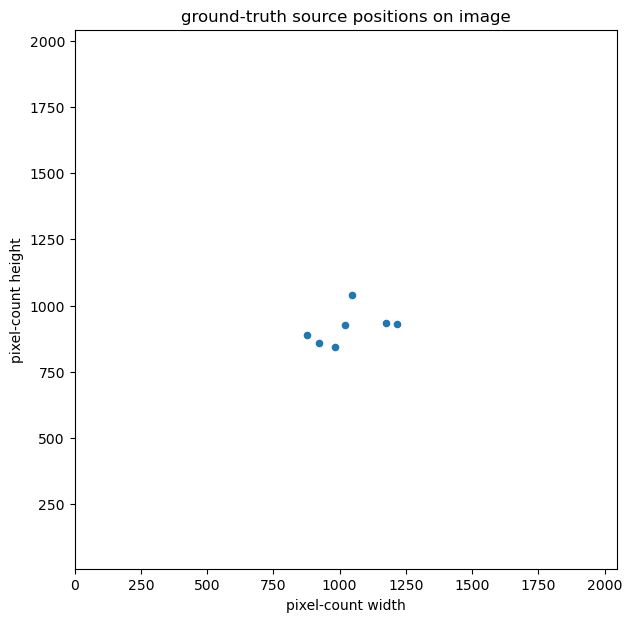

In [11]:
fig, ax = plt.subplots(
    figsize=(7, 7),
)
sc = ax.scatter(ground_truth[0], ground_truth[1], s=20)

# for idx, i in enumerate(range(ground_truth[0].shape[0])):
#     ax.annotate(sky[idx,-1], (ground_truth[0][i], ground_truth[1][i]))

plt.axis("equal")
plt.title("ground-truth source positions on image")
plt.xlim((0, imaging_npixel))
plt.ylim((0, imaging_npixel))
plt.xlabel("pixel-count width")
plt.ylabel("pixel-count height")
plt.show()

In [12]:
assignments_dirty = (
    SourceDetectionEvaluation.automatic_assignment_of_ground_truth_and_prediction(
        ground_truth=ground_truth.T,
        detected=detection_result_dirty.get_pixel_position_of_sources().T,
        max_dist=10,
        top_k=3,
    )
)
assignments_dirty

array([[-1.        ,  1.        ,         inf],
       [-1.        ,  2.        ,         inf],
       [ 0.        , -1.        ,         inf],
       [ 1.        , -1.        ,         inf],
       [ 2.        , -1.        ,         inf],
       [ 3.        ,  0.        ,  3.38124041],
       [ 4.        , -1.        ,         inf],
       [ 5.        , -1.        ,         inf],
       [ 6.        , -1.        ,         inf]])

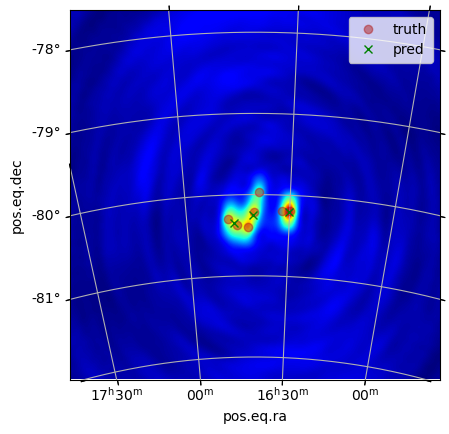

In [13]:
sde_dirty = SourceDetectionEvaluation(
    sky=sky,
    ground_truth=ground_truth,
    assignments=assignments_dirty,
    sky_idxs=sky_idxs,
    source_detection=detection_result_dirty,
)
sde_dirty.plot()

### Imaging
Of course, we can also do source detection on cleaned (clean algorithmus by rascil) images.

In [14]:
imager_askap.ingest_chan_per_blockvis = 1
imager_askap.ingest_vis_nchan = 16

# Try differnet algorithm
# More sources
deconvolved, restored, residual = imager_askap.imaging_rascil(
    clean_nmajor=0,
    clean_algorithm="mmclean",
    clean_scales=[0, 6, 10, 30, 60],
    clean_fractional_threshold=0.3,
    clean_threshold=0.12e-3,
    clean_nmoment=5,
    clean_psf_support=640,
    clean_restored_output="integrated",
)

{'npixel': 2048, 'nchan': 1, 'cellsize': 3.878509448876288e-05, 'override_cellsize': False, 'polarisation_frame': <rascil.data_models.polarisation.PolarisationFrame object at 0x7f56840bd6a0>}
override_cellsize = False
type override_cellsize = <class 'bool'>
cellsize = 3.878509448876288e-05
cellsize = 3.878509448876288e-05
{'npixel': 2048, 'nchan': 1, 'cellsize': 3.878509448876288e-05, 'override_cellsize': False, 'polarisation_frame': <rascil.data_models.polarisation.PolarisationFrame object at 0x7f56840bd6a0>}
override_cellsize = False
type override_cellsize = <class 'bool'>
cellsize = 3.878509448876288e-05
cellsize = 3.878509448876288e-05
{'npixel': 2048, 'nchan': 1, 'cellsize': 3.878509448876288e-05, 'override_cellsize': False, 'polarisation_frame': <rascil.data_models.polarisation.PolarisationFrame object at 0x7f56840bd6a0>}
override_cellsize = False
type override_cellsize = <class 'bool'>
cellsize = 3.878509448876288e-05
cellsize = 3.878509448876288e-05
{'npixel': 2048, 'nchan': 1,

## Analysis via Source Detection

Source Detection on restored image.

In [15]:
detection_result = PyBDSFSourceDetectionResult.detect_sources_in_image(restored)

--> Opened '/home/vincenzo/Karabo-Pipeline/karabo/examples/karabo_folder/cdb7bc6a-aa7f-4fa0-9bcc-4cb311209ceb'
Image size .............................. : (2048, 2048) pixels
Number of channels ...................... : 1
Number of Stokes parameters ............. : 1
Beam shape (major, minor, pos angle) .... : (1.24905e-01, 5.02928e-02, -3.5) degrees
Frequency of image ...................... : 100.000 MHz
Number of blank pixels .................. : 0 (0.0%)
Flux from sum of (non-blank) pixels ..... : 18.901 Jy
--> Calculating background rms and mean images
Derived rms_box (box size, step size) ... : (1771, 205) pixels
--> Size of rms_box larger than 1/4 of image size
--> Using constant background rms and mean
Value of background rms ................. : 5.71e-03 Jy/beam
Value of background mean ................ : 0.00224 Jy/beam
--> Expected 5-sigma-clipped false detection rate < fdr_ratio
--> Using sigma-clipping ('hard') thresholding
Minimum number of pixels per island ..... : 480
Numb

Fitting islands with Gaussians .......... : [|] 0/1Fitting islands with Gaussians .......... : [] 1/1[-3G

Total number of Gaussians fit to image .. : 9
Total flux density in model ............. : 10.361 Jy
--> Grouping Gaussians into sources


Number of sources formed from Gaussians   : 3


--> Wrote ASCII file '/home/vincenzo/Karabo-Pipeline/karabo/examples/karabo_folder/80f972b2-2759-4cf0-a266-8a5fac856696'
--> Wrote file '/home/vincenzo/Karabo-Pipeline/karabo/examples/karabo_folder/e9d8ab48-6d5e-4c4c-9f57-4c29934a616a'


## Evaluation

In [16]:
assignments_restored = (
    SourceDetectionEvaluation.automatic_assignment_of_ground_truth_and_prediction(
        ground_truth=ground_truth.T,
        detected=detection_result.get_pixel_position_of_sources().T,
        max_dist=10,
        top_k=3,
    )
)
assignments_restored

array([[-1.        ,  0.        ,         inf],
       [-1.        ,  1.        ,         inf],
       [-1.        ,  5.        ,         inf],
       [ 0.        ,  6.        ,  2.05954461],
       [ 1.        ,  2.        ,  1.26416831],
       [ 2.        ,  7.        ,  1.14426213],
       [ 3.        ,  4.        ,  2.49646886],
       [ 4.        ,  3.        ,  4.05263048],
       [ 5.        , -1.        ,         inf],
       [ 6.        ,  8.        ,  1.20681079]])

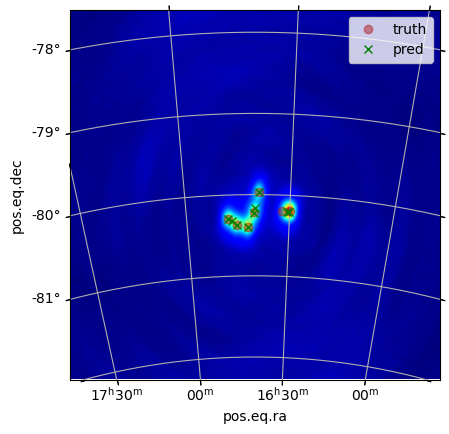

In [17]:
# Create mapping plots
sde_restored = SourceDetectionEvaluation(
    sky=sky,
    ground_truth=ground_truth,
    assignments=assignments_restored,
    sky_idxs=sky_idxs,
    source_detection=detection_result,
)
sde_restored.plot()

In [18]:
# Confusion Matrix
sde_restored.get_confusion_matrix()

array([[0., 3.],
       [1., 6.]])

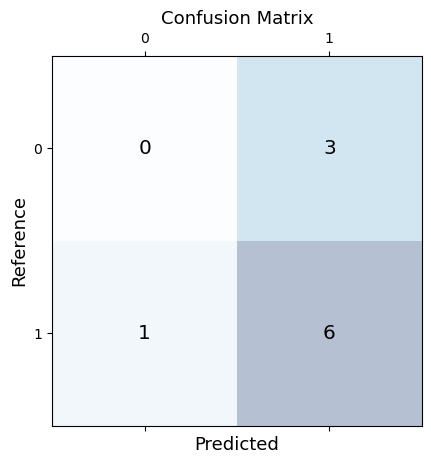

In [19]:
sde_restored.plot_confusion_matrix()

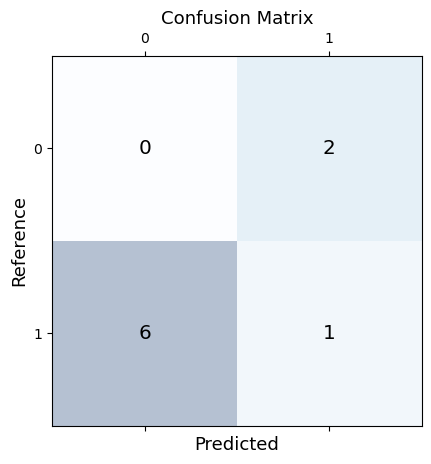

In [20]:
sde_dirty.plot_confusion_matrix()

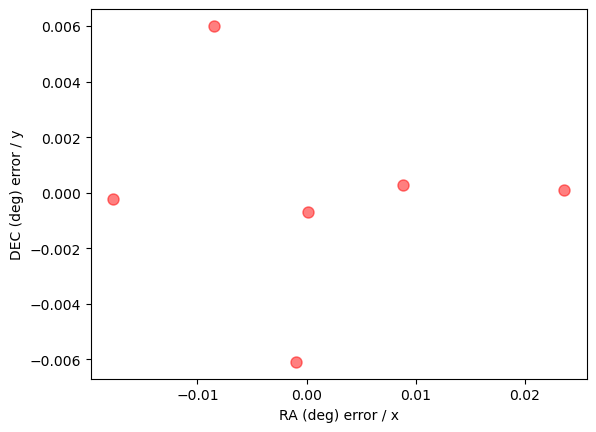

In [21]:
# Plot error ra and dec
sde_restored.plot_error_ra_dec()

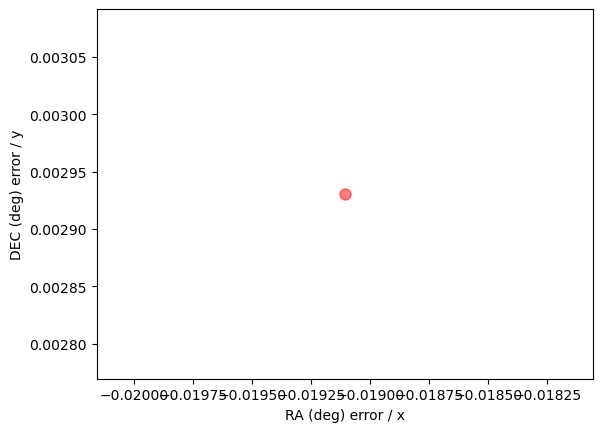

In [22]:
# Plot error ra and dec
sde_dirty.plot_error_ra_dec()

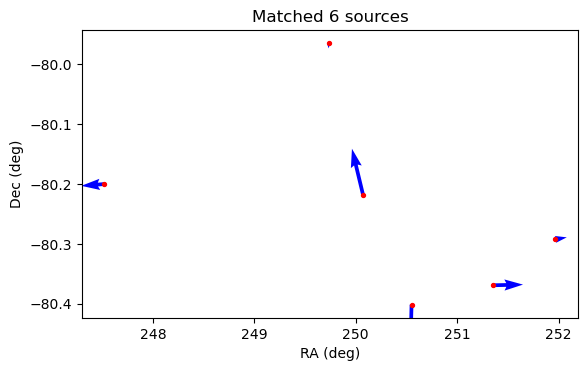

In [23]:
# Plot error flux
sde_restored.plot_quiver_positions()

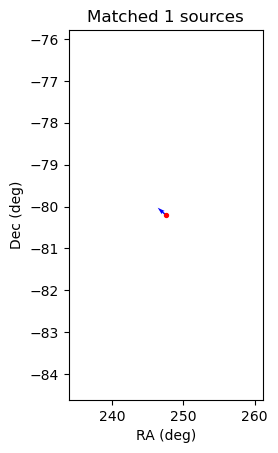

In [24]:
# Plot error flux
sde_dirty.plot_quiver_positions()

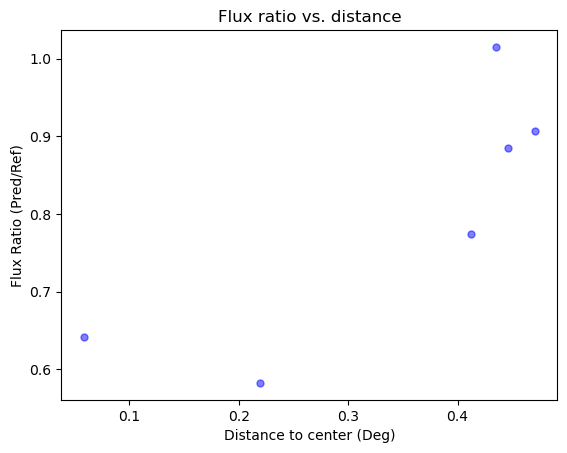

In [25]:
# Plot error ra and dec
sde_restored.plot_flux_ratio_to_distance()

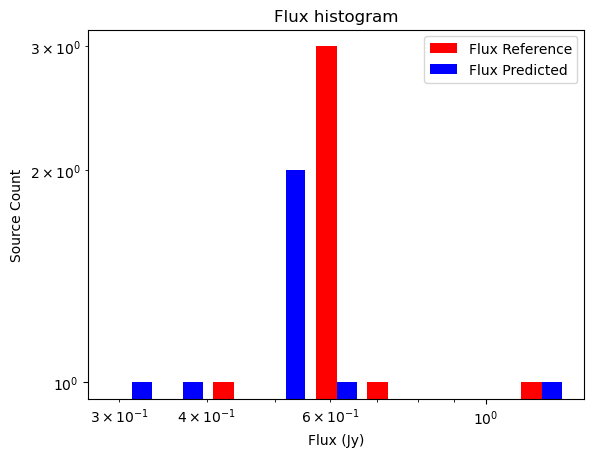

In [26]:
# Plot error ra and dec
sde_restored.plot_flux_histogram()

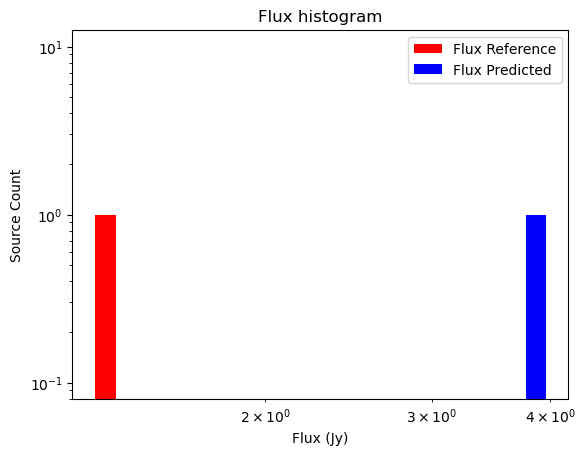

In [27]:
# Plot error ra and dec
sde_dirty.plot_flux_histogram()

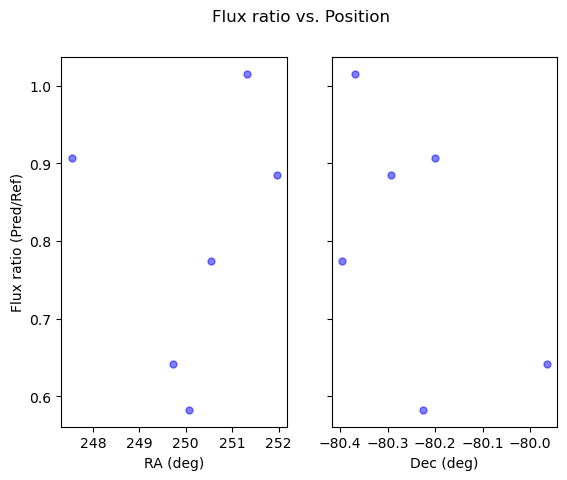

In [28]:
# Plot error ra and dec
sde_restored.plot_flux_ratio_to_ra_dec()

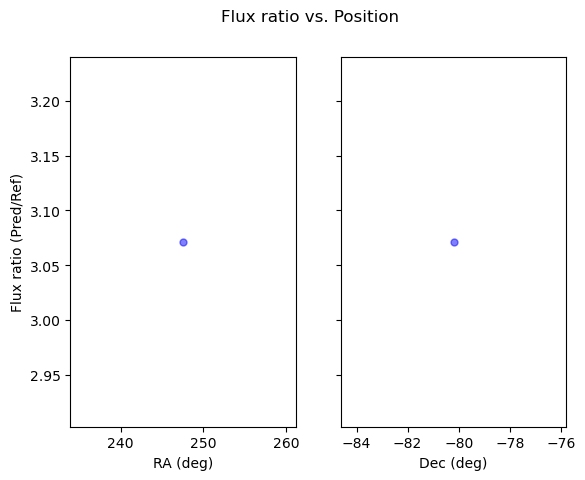

In [29]:
# Plot error ra and dec
sde_dirty.plot_flux_ratio_to_ra_dec()

In [30]:
from karabo.util.FileHandle import FileHandle

# Clean up, if you want to
fh = FileHandle()
fh.clean_up()